## Graduate Trainee Technical Assessment - Mukundi Ramanyimi

### Business Case


RetailCore Bank is a mid-sized retail bank serving over 2 million customers across multiple product lines including transactional accounts, credit cards, personal loans, and savings products. Like most retail banks, RetailCore faces a significant challenge: although customer data is abundant, the bank struggles to translate it into personalised experiences that drive engagement and retention.


The bank’s marketing team currently sends the same product campaigns to all customers regardless of behaviour, lifecycle stage, or financial profile. This results in:

• Low campaign conversion rates due to irrelevant product offers

• Customer churn from high-value segments who feel underserved

• Missed cross-sell and upsell opportunities worth an estimated R180M annually

• Executive leadership lacking clear visibility into customer segmentation health


To address this, the AI Engineering team has been tasked with building a proof-of-concept Customer Intelligence Platform. The platform must segment customers into meaningful behavioural clusters, generate personalised product recommendations, and surface AI-generated explanations that non-technical executives can act on.


As a new member of the team, you are being asked to independently build this proof-of-concept end-to-end.

# 1. DATA GENERATION

For the dataset, the given customer features make the dataset realistic, but I decided to add further features to make the dataset robust. Features such as marital_status, customer_id, and gender. I used Anthropic Claude to write the dataset.

## Prompt:

I am building a customer segmentation and personalisation system for a fictional bank as part of a customer intelligence platform project. I need you to generate a realistic synthetic dataset of 600 bank customers that will later be used for machine learning tasks, specifically unsupervised clustering to segment customers, product recommendation based on cluster profiles.

The data must be as realistic as possible, features should not be independent of each other. There should be meaningful correlations between them. For example, income should influence which products a customer holds.

The dataset should include these features:

Identifiers: customer_id, first_name, last_name — use South African names and a simple ID format like CUST-00001. No real ID numbers - Might have a conflict.
Demographic: age, gender, marital_status, number_of_dependents, education_level, province, employment_status
Financial: monthly_income, income_band, monthly_expenses, account_tenure_years
Behavioural: monthly_transactions, avg_transaction_value, digital_login_frequency, branch_visit_count, late_payment_count
Product: has_savings_account, has_credit_card, has_home_loan, has_personal_loan, has_vehicle_finance, has_investment_account, active_products_count
Risk: credit_score, loan_utilisation_rate, days_since_last_default
Target: churn_risk_label (Low / Medium / High)

You can also add other features that you think are relevant.

I do not want you to produce a CSV file directly. Instead, I want you to write me the Python code that generates this dataset. The code should include comments explaining the reasoning behind the key correlation decisions so I can understand the choices.


The data generation script, written by  Claude, is in /data/data_generation.py

In [69]:
# Generate synthetic bank customer dataset

from data.data_generation import generate_synthetic_bank_customers
generate_synthetic_bank_customers(N=2000, OUTPUT_PATH="data/bank_customers.csv")


✓ Dataset saved to 'data/bank_customers.csv'


# 2. EXPLOLATORY DATA ANALYSIS

This step includes cleaning data of any inconsistencies, validating the data and discovering meaningful patterns. These helps in making sure we have good data quality. Data quality is important in clustering.

In [70]:
# Import pandas and numpy for data manipulation

import pandas as pd
import numpy as np

# Import matplotlib and seaborn for visualization

import matplotlib.pyplot as plt
import seaborn as sns


In [71]:
# Load the data

df = pd.read_csv("data/bank_customers.csv")


##  Inspection

In [72]:
# Validate the data shape
df.shape

(2000, 31)

In [73]:
# Preview the data
df.head()

,customer_id,first_name,last_name,age,gender,marital_status,number_of_dependents,education_level,province,employment_status,...,has_credit_card,has_home_loan,has_personal_loan,has_vehicle_finance,has_investment_account,active_products_count,credit_score,loan_utilisation_rate,days_since_last_default,churn_risk_label
0,CUST-00001,Mihlali,Mthembu,33,Female,Single,1,Degree,Eastern Cape,Employed,...,1,1,1,1,1,6,588,0.457,9999,Low
1,CUST-00002,Thabo,Nxumalo,25,Male,Single,0,Degree,Gauteng,Employed,...,1,0,1,1,0,4,603,0.277,9999,Low
2,CUST-00003,Sipho,Daniels,36,Male,Married,0,No Matric,Gauteng,Self-Employed,...,0,0,0,0,0,1,611,0.000,9999,High
3,CUST-00004,Jade,Pillay,37,Female,Single,0,Postgraduate,KwaZulu-Natal,Employed,...,1,1,1,0,0,4,676,0.377,1480,Low
4,CUST-00005,Mihlali,Daniels,35,Female,Married,3,Matric,Eastern Cape,Unemployed,...,0,0,0,0,0,0,379,0.000,108,High


In [74]:
# Check numeric ranges
df.describe()

,age,number_of_dependents,monthly_income,monthly_expenses,account_tenure_years,monthly_transactions,avg_transaction_value,digital_login_frequency,branch_visit_count,late_payment_count,has_savings_account,has_credit_card,has_home_loan,has_personal_loan,has_vehicle_finance,has_investment_account,active_products_count,credit_score,loan_utilisation_rate,days_since_last_default
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000
mean,37.319500,1.135000,19032.368235,11739.400000,5.914250,22.8350,514.223455,13.971500,3.580000,2.06150,0.882500,0.469000,0.293000,0.380500,0.33650,0.157500,2.5190,586.563500,0.329344,4468.815000
std,11.508547,1.277337,19649.299433,11755.215446,3.295884,15.0438,414.547469,6.744066,2.093751,1.83232,0.322096,0.499163,0.455252,0.485631,0.47263,0.364363,1.6006,84.409155,0.242145,4504.386191
min,18.000000,0.000000,0.000000,0.000000,0.500000,3.0000,50.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.0000,300.000000,0.000000,10.000000
25%,29.000000,0.000000,4500.000000,3100.000000,3.500000,12.0000,216.552500,9.000000,2.000000,1.00000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,1.0000,533.000000,0.000000,466.750000
50%,34.000000,1.000000,12400.000000,8000.000000,5.800000,20.0000,448.545000,14.000000,3.000000,2.00000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,2.0000,593.000000,0.388500,1577.500000
75%,44.000000,2.000000,27200.000000,16100.000000,8.100000,31.0000,702.437500,18.000000,5.000000,3.00000,1.000000,1.000000,1.000000,1.000000,1.00000,0.000000,4.0000,646.000000,0.506250,9999.000000
max,75.000000,6.000000,126200.000000,90300.000000,19.000000,103.0000,4107.110000,38.000000,13.000000,10.00000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,6.0000,835.000000,1.000000,9999.000000


## Missing Values and Data Types

In [75]:
# Check basic data structure
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customer_id              2000 non-null   str    
 1   first_name               2000 non-null   str    
 2   last_name                2000 non-null   str    
 3   age                      2000 non-null   int64  
 4   gender                   2000 non-null   str    
 5   marital_status           2000 non-null   str    
 6   number_of_dependents     2000 non-null   int64  
 7   education_level          2000 non-null   str    
 8   province                 2000 non-null   str    
 9   employment_status        2000 non-null   str    
 10  monthly_income           2000 non-null   float64
 11  income_band              2000 non-null   str    
 12  monthly_expenses         2000 non-null   float64
 13  account_tenure_years     2000 non-null   float64
 14  monthly_transactions     2000 non-n

In [76]:
# Check for missing values
df.isnull().sum()

customer_id                0
first_name                 0
last_name                  0
age                        0
gender                     0
marital_status             0
number_of_dependents       0
education_level            0
province                   0
employment_status          0
monthly_income             0
income_band                0
monthly_expenses           0
account_tenure_years       0
monthly_transactions       0
avg_transaction_value      0
digital_login_frequency    0
branch_visit_count         0
late_payment_count         0
preferred_channel          0
has_savings_account        0
has_credit_card            0
has_home_loan              0
has_personal_loan          0
has_vehicle_finance        0
has_investment_account     0
active_products_count      0
credit_score               0
loan_utilisation_rate      0
days_since_last_default    0
churn_risk_label           0
dtype: int64

In [77]:
df.duplicated().sum()

np.int64(0)

In [78]:
# Validate Categorical values
df["gender"].unique(), df["marital_status"].unique(), df["education_level"].unique(), df["employment_status"].unique()

(<StringArray>
 ['Female', 'Male']
 Length: 2, dtype: str,
 <StringArray>
 ['Single', 'Married', 'Divorced', 'Widowed']
 Length: 4, dtype: str,
 <StringArray>
 ['Degree', 'No Matric', 'Postgraduate', 'Matric', 'Diploma']
 Length: 5, dtype: str,
 <StringArray>
 ['Employed', 'Self-Employed', 'Unemployed', 'Retired', 'Student']
 Length: 5, dtype: str)

#### Summary

No null values were found across all the columns. Data types are correct for all features. For all the numerical features, the value ranges fall within the expected bounds. There are no duplicates. All categorical features have correct options.

Consistent with the controlled generation process.

## Outlier Detection

Uses InterQuartile Range (IQR) method.



In [79]:
numerical_cols = [
    'age', 'monthly_income', 'credit_score', 'loan_utilisation_rate',
    'monthly_transactions', 'avg_transaction_value', 'digital_login_frequency',
    'account_tenure_years', 'monthly_expenses'
]

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    if len(outliers) > 0:
        print(f"{col}: {len(outliers)} outliers | range [{lower:.1f}, {upper:.1f}]")

age: 28 outliers | range [6.5, 66.5]
monthly_income: 84 outliers | range [-29550.0, 61250.0]
credit_score: 17 outliers | range [363.5, 815.5]
monthly_transactions: 56 outliers | range [-16.5, 59.5]
avg_transaction_value: 57 outliers | range [-512.3, 1431.3]
digital_login_frequency: 12 outliers | range [-4.5, 31.5]
account_tenure_years: 11 outliers | range [-3.4, 15.0]
monthly_expenses: 98 outliers | range [-16400.0, 35600.0]


In [80]:
numerical_cols = [
    'age', 'monthly_income', 'credit_score', 'loan_utilisation_rate',
    'monthly_transactions', 'avg_transaction_value', 'digital_login_frequency',
    'account_tenure_years', 'monthly_expenses'
]

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    lower_outliers = df[df[col] < lower]
    upper_outliers = df[df[col] > upper]
    
    print(f"{col}:")
    print(f"  Actual data range: [{df[col].min():.1f}, {df[col].max():.1f}]")
    print(f"  IQR bounds: [{lower:.1f}, {upper:.1f}]")
    print(f"  Below lower bound: {len(lower_outliers)} | Above upper bound: {len(upper_outliers)}\n")

age:
  Actual data range: [18.0, 75.0]
  IQR bounds: [6.5, 66.5]
  Below lower bound: 0 | Above upper bound: 28

monthly_income:
  Actual data range: [0.0, 126200.0]
  IQR bounds: [-29550.0, 61250.0]
  Below lower bound: 0 | Above upper bound: 84

credit_score:
  Actual data range: [300.0, 835.0]
  IQR bounds: [363.5, 815.5]
  Below lower bound: 15 | Above upper bound: 2

loan_utilisation_rate:
  Actual data range: [0.0, 1.0]
  IQR bounds: [-0.8, 1.3]
  Below lower bound: 0 | Above upper bound: 0

monthly_transactions:
  Actual data range: [3.0, 103.0]
  IQR bounds: [-16.5, 59.5]
  Below lower bound: 0 | Above upper bound: 56

avg_transaction_value:
  Actual data range: [50.0, 4107.1]
  IQR bounds: [-512.3, 1431.3]
  Below lower bound: 0 | Above upper bound: 57

digital_login_frequency:
  Actual data range: [0.0, 38.0]
  IQR bounds: [-4.5, 31.5]
  Below lower bound: 0 | Above upper bound: 12

account_tenure_years:
  Actual data range: [0.5, 19.0]
  IQR bounds: [-3.4, 15.0]
  Below lowe

Outliers were detected in several numerical features using the IQR method, mostly on the upper-end values representing high-income, high-activity customer segments. These are not data errors. Hence, the outliers were not removed as they represent genuine customer behaviour. This will be attended to during preprocessing, as this informs our scaling method. Because of these outliers, we will use RobustScaler during preprocessing.

## Categorical Distribution

These distributions inform on the percentages of the categories in the categorical data.

In [81]:
categorical_cols = [
    'income_band', 'employment_status', 'province', 
    'marital_status', 'education_level', 'preferred_channel', 
    'churn_risk_label'
]

for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')


income_band:
income_band
LSM 1-4           36.0%
LSM 5-6           30.0%
LSM 7-8           19.6%
Affluent          12.8%
High Net Worth     1.6%
Name: proportion, dtype: str

employment_status:
employment_status
Employed         58.9%
Unemployed       17.8%
Self-Employed    14.4%
Retired           6.7%
Student           2.2%
Name: proportion, dtype: str

province:
province
Gauteng          25.3%
KwaZulu-Natal    19.0%
Western Cape     13.1%
Limpopo          11.4%
Eastern Cape     10.8%
Mpumalanga        8.9%
North West        6.6%
Free State        3.6%
Northern Cape     1.4%
Name: proportion, dtype: str

marital_status:
marital_status
Married     49.8%
Single      44.0%
Divorced     5.4%
Widowed      0.8%
Name: proportion, dtype: str

education_level:
education_level
Matric          32.8%
Diploma         26.1%
Degree          22.1%
No Matric       11.2%
Postgraduate     7.8%
Name: proportion, dtype: str

preferred_channel:
preferred_channel
Digital-Preferred    63.6%
Branch-Preferred

Note: LSM here is the Living Standard Measure (LSM), a South African consumer segmentation tool developed by SAARF (South African Audience Research Foundation) that classifies people from LSM 1 (lowest) to LSM 10 (highest) based on household assets and access to services rather than just income.

## Preprocessing for Days since last default

In [82]:
# Check the range and counts of 'days_since_last_default'
df['days_since_last_default'].value_counts().sort_index()

days_since_last_default
10       17
12        4
13        2
14        1
15        1
       ... 
3436      1
3511      1
3574      1
3650     27
9999    787
Name: count, Length: 874, dtype: int64

In [83]:
# Check how many customers have 9999 days since last default (indicating no defaults)
(df['days_since_last_default'] == 9999).sum()

np.int64(787)

#### Handling the Value 9999 

When generating the data, Claude used the 9999 for customers who have never defaulted on their payments. The value 9999 does not, in this case, mean that the customer last defaulted 9999 days ago. 

To deal with this, we can replace the 9999 value with a large realistic value. For instance, we can replace the 9999 value with 2000, meaning the customer last defaulted 2000 days ago. However, this is problematic since the information is no longer accurate. These customers have never defaulted. 

The better option is to actually use a binary flag. This will indicate whether the customer has ever defaulter or not. This is a clean and interpretable option. Furthermore, there is no loss of information.

In [84]:
# Create a new feature that indicates whether a customer has ever defaulted
df['has_ever_defaulted'] = (df['days_since_last_default'] != 9999).astype(int)
df['days_since_last_default'] = df['days_since_last_default'].replace(999, 0)



## Correlations

In [85]:
# Verify relationships

# Check that education has influence on income
df.groupby("education_level")["monthly_income"].mean().sort_values()

# Postgraduate > Degree > Diploma > Matric > No matric 

education_level
No Matric        3846.561839
Matric           6988.763470
Diploma         15845.655690
Degree          33969.809457
Postgraduate    59802.868782
Name: monthly_income, dtype: float64

In [86]:
# Chrck that late payments has influence on credit score
df.groupby("late_payment_count")["credit_score"].mean().sort_values()

# Late payment counts have low credit scores

late_payment_count
10    300.000000
9     310.500000
8     361.266667
7     403.950000
6     425.285714
5     470.401575
4     509.643564
3     554.238411
2     590.428969
1     624.194444
0     667.783058
Name: credit_score, dtype: float64

In [87]:
# Check that older people have had their accounts for longer

df.groupby("age")["account_tenure_years"].mean().sort_values()

age
18    1.100000
20    1.825000
19    2.043750
21    2.507143
67    2.875000
22    2.989655
24    3.347222
23    3.639535
25    3.932143
59    4.566667
68    4.640000
44    4.957895
73    5.066667
65    5.250000
63    5.484615
36    5.655556
74    5.675000
26    5.696610
55    5.727778
47    5.735294
27    5.845763
75    5.850000
43    5.882051
46    5.930769
28    5.938961
56    5.980000
66    5.980000
49    6.038462
50    6.081818
31    6.103488
39    6.120000
60    6.165000
70    6.200000
69    6.220000
53    6.232143
61    6.266667
30    6.271277
51    6.348148
38    6.370833
62    6.388889
34    6.413402
45    6.491892
29    6.496512
37    6.576667
57    6.618750
41    6.636170
58    6.661538
33    6.662745
40    6.674138
52    6.839286
32    6.886598
35    6.940260
72    6.950000
48    6.958824
64    7.292308
54    7.456522
42    8.278125
Name: account_tenure_years, dtype: float64

In [88]:
# Income VS Expense ratio
(df["monthly_expenses"] / df["monthly_income"]).describe()

count    1989.000000
mean        0.684923
std         0.181635
min         0.000000
25%         0.554017
50%         0.646643
75%         0.748031
max         1.974334
dtype: float64

In [89]:
# Check for churn correlations
df.groupby("churn_risk_label")[["credit_score","loan_utilisation_rate","late_payment_count","active_products_count","digital_login_frequency"]].mean()

,credit_score,loan_utilisation_rate,late_payment_count,active_products_count,digital_login_frequency
churn_risk_label,,,,,
High,520.255000,0.236373,3.107500,1.125000,12.365
Low,631.204000,0.408196,1.489000,3.764000,15.302
Medium,556.368333,0.259905,2.318333,1.373333,12.825


## Visualizations

Here we visualize the Data

### Monthly Income Histogram - Visualizes the distribution of the monthly income

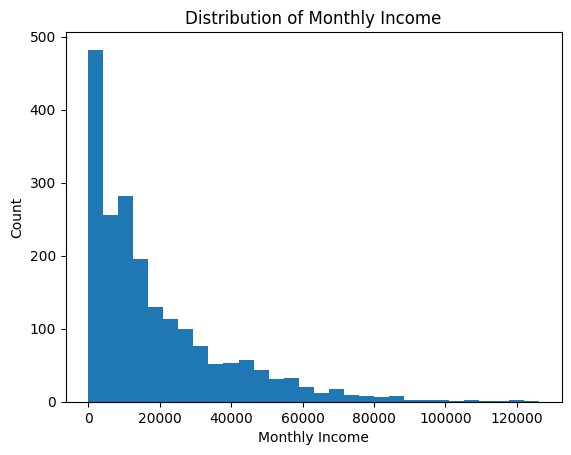

In [90]:
# Plot the monthly income distribution. We should see a right skewed distribution with a long taiL. 
# Average income should be around 25k, with most people earning below 10k
plt.hist(df["monthly_income"], bins=30)
plt.title("Distribution of Monthly Income")
plt.xlabel("Monthly Income")    
plt.ylabel("Count")
plt.show()

### Monthly Income by Education Level Plot

Visualize the relationship between education level and monthly income using a boxplot. We should see a clear increase in median income as education level increases, with postgraduate having the highest median income and no matric having the lowest.

We use boxplots as we are comparing catorigical variable (education level) with a numeric variable (monthly income). Boxplots show the median, quartiles, and potential outliers, which is ideal for understanding the distribution of income across different education levels. 

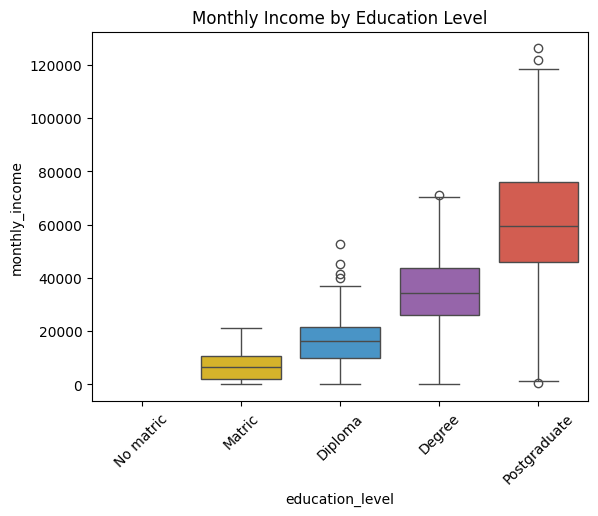

In [91]:
sns.boxplot(x="education_level", y="monthly_income", data=df, 
            order=["No matric", "Matric", "Diploma", "Degree", "Postgraduate"],
            palette={"No matric":"#2ecc71", "Matric":"#f1c40f", "Diploma":"#3498db", "Degree":"#9b59b6", "Postgraduate":"#e74c3c"})
plt.title("Monthly Income by Education Level")
plt.xticks(rotation=45)
plt.show()

We can also use a bar graph, but it will only show the mean income for each education level, without providing insights into the distribution or variability of income within each group. Boxplots provide a more comprehensive view of the data, making them more suitable for this analysis.


(array([0, 1, 2, 3, 4]),
 [Text(0, 0, 'Degree'),
  Text(1, 0, 'Diploma'),
  Text(2, 0, 'Matric'),
  Text(3, 0, 'No Matric'),
  Text(4, 0, 'Postgraduate')])

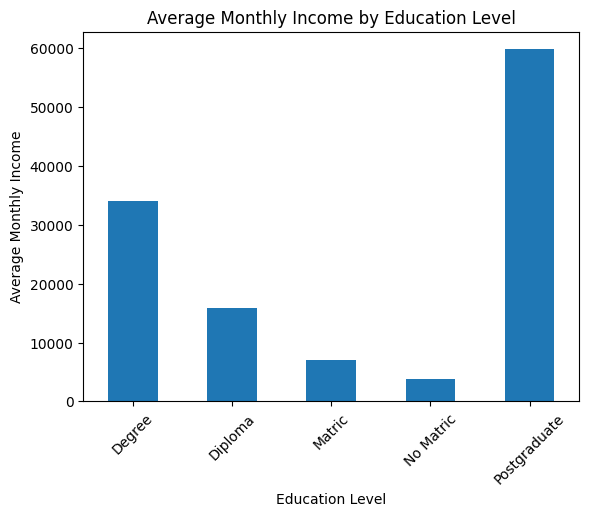

In [92]:
df.groupby("education_level")["monthly_income"].mean().plot(kind="bar")
plt.title("Average Monthly Income by Education Level")
plt.xlabel("Education Level")
plt.ylabel("Average Monthly Income")
plt.xticks(rotation=45)

A more comprehensive view of the data is provided by violin plots, which show the distribution of income for each education level, including the median, quartiles, and density of the data. This allows us to see not only the central tendency but also the variability and potential outliers in income across different education levels.


Text(0.5, 1.0, 'Monthly Income Distribution by Education Level')

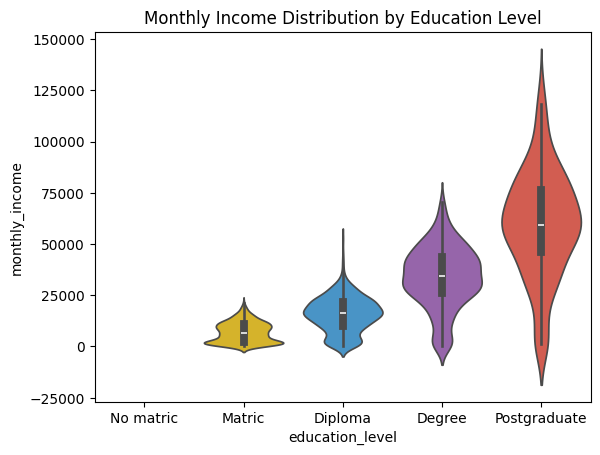

In [93]:
sns.violinplot(x = "education_level", y = "monthly_income", data=df, 
               order=["No matric", "Matric", "Diploma", "Degree", "Postgraduate"],
               palette={"No matric":"#2ecc71", "Matric":"#f1c40f", "Diploma":"#3498db", "Degree":"#9b59b6", "Postgraduate":"#e74c3c"})
plt.title("Monthly Income Distribution by Education Level")

### Correlation Heatmap / Matrix

The correlation heatmap shows the Pearson correlation coefficient between every pair of the numerical features.

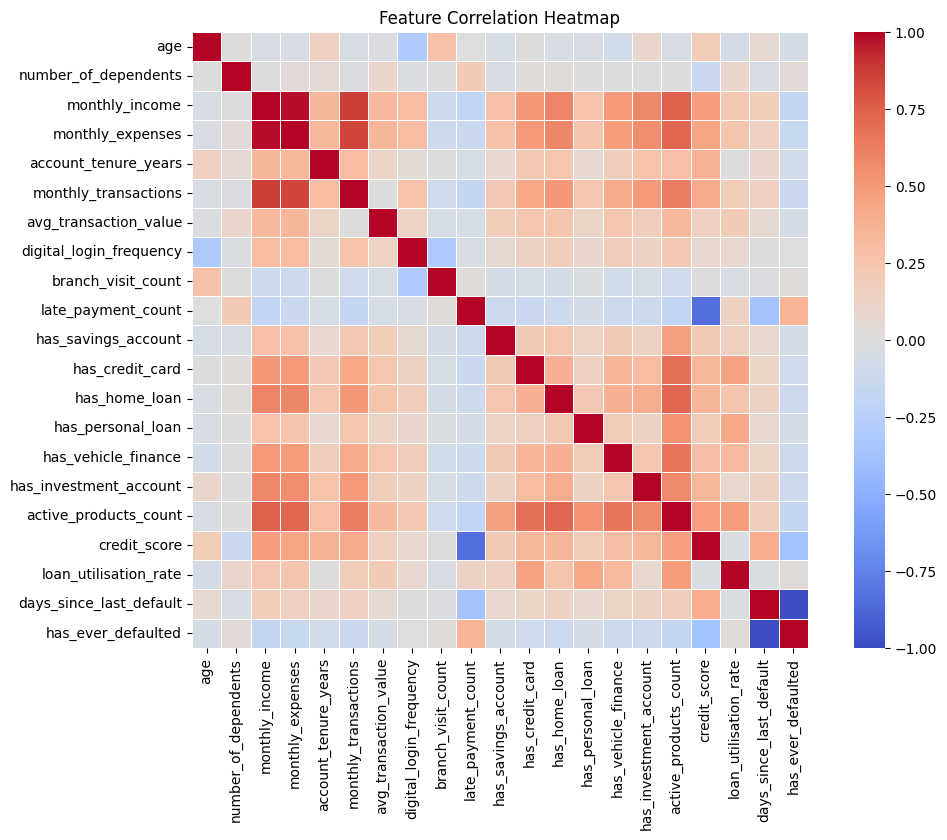

In [94]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=False, cmap="coolwarm", fmt=".2f", center=0,
            square= True, linewidths=0.5, vmin=-1, vmax=1)
plt.title("Feature Correlation Heatmap")
plt.show()

#### High Correlation between Income and Expenses Handling

The correlation coefficient between monthly income and expenses is extremely high, approximately 0.97. Since these two features are highly correlated, we will engineer a new feature that captures the relationship between these two. This feature will show financial health of the customer and will be more meaningful than income and expenses. This feature will be named savings_rate.

In [95]:
df['savings_rate'] = (
    (df['monthly_income'] - df['monthly_expenses']) / df['monthly_income']
).replace([np.inf, -np.inf], np.nan).fillna(0)
df['savings_rate'].describe()

count    2000.000000
mean        0.313344
std         0.182628
min        -0.974334
25%         0.249923
50%         0.352226
75%         0.445610
max         1.000000
Name: savings_rate, dtype: float64

#### savings_rate NaN Handling

11 rows produced NaN values when computing savings_rate due to division edge 
cases. These were filled with 0, representing customers with no measurable 
savings capacity. No rows were dropped.

### Credit Score by Churn Risk Category Boxplot

Boxplot showing distribution of credit scores by churn risk label

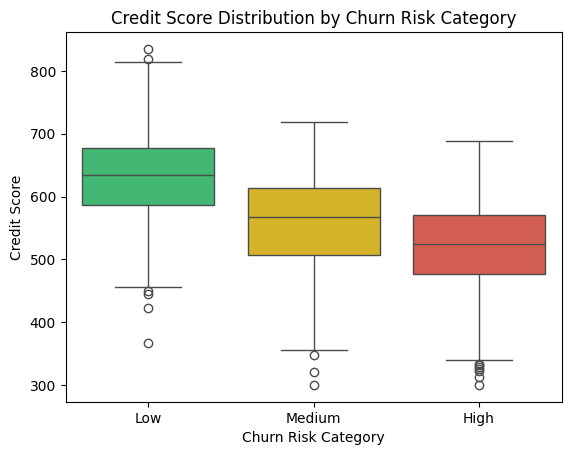

In [96]:
# Churn correlations

sns.boxplot(x="churn_risk_label", y="credit_score", data=df, order=["Low", "Medium", "High"],
            palette={"Low":"#2ecc71", "Medium":"#f1c40f", "High":"#e74c3c"})
plt.title("Credit Score Distribution by Churn Risk Category")
plt.xlabel("Churn Risk Category")
plt.ylabel("Credit Score")
plt.show()

### Product Ownership by Income Band Plot

Visualize product ownership for each income band. We won't include savings account as every customer has one.

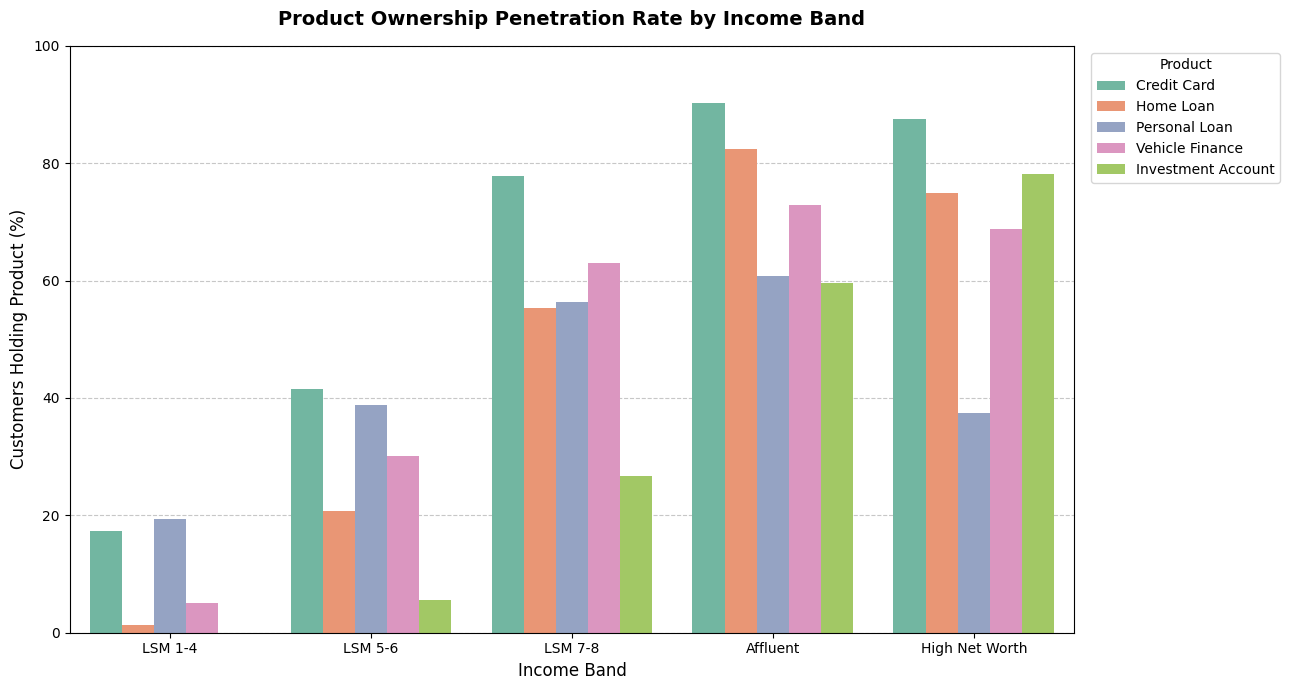

In [97]:
product_cols = [
    'has_credit_card', 'has_home_loan', 'has_personal_loan',
    'has_vehicle_finance', 'has_investment_account'
]

income_order = ["LSM 1-4", "LSM 5-6", "LSM 7-8", "Affluent", "High Net Worth"]

# Calculate penetration rate (% of customers in each band who hold each product)
penetration = (
    df.groupby('income_band')[product_cols]
    .mean()                         
    .mul(100)                        
    .reindex(income_order)          
    .reset_index()
)

# Reshape from wide to long format — seaborn needs this for grouped bar charts
penetration_long = penetration.melt(
    id_vars='income_band',
    var_name='product',
    value_name='penetration_rate'
)

penetration_long['product'] = penetration_long['product'].str.replace('has_', '').str.replace('_', ' ').str.title()

fig, ax = plt.subplots(figsize=(13, 7))

sns.barplot(
    data=penetration_long,
    x='income_band',
    y='penetration_rate',
    hue='product',
    order=income_order,
    palette='Set2',
    ax=ax
)

ax.set_title("Product Ownership Penetration Rate by Income Band",
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Income Band", fontsize=12)
ax.set_ylabel("Customers Holding Product (%)", fontsize=12)
ax.legend(title="Product", bbox_to_anchor=(1.01, 1), loc='upper left')
ax.set_ylim(0, 100)
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

### Customer Behavioral Profiles Across Churn Risk Category

Visualize customer behaviour profiles across churn risk categories by looking at engagement metrics like digital login frequency, monthly transactions, and active products count. We should see that high churn risk customers have lower engagement levels compared to low churn risk customers.  

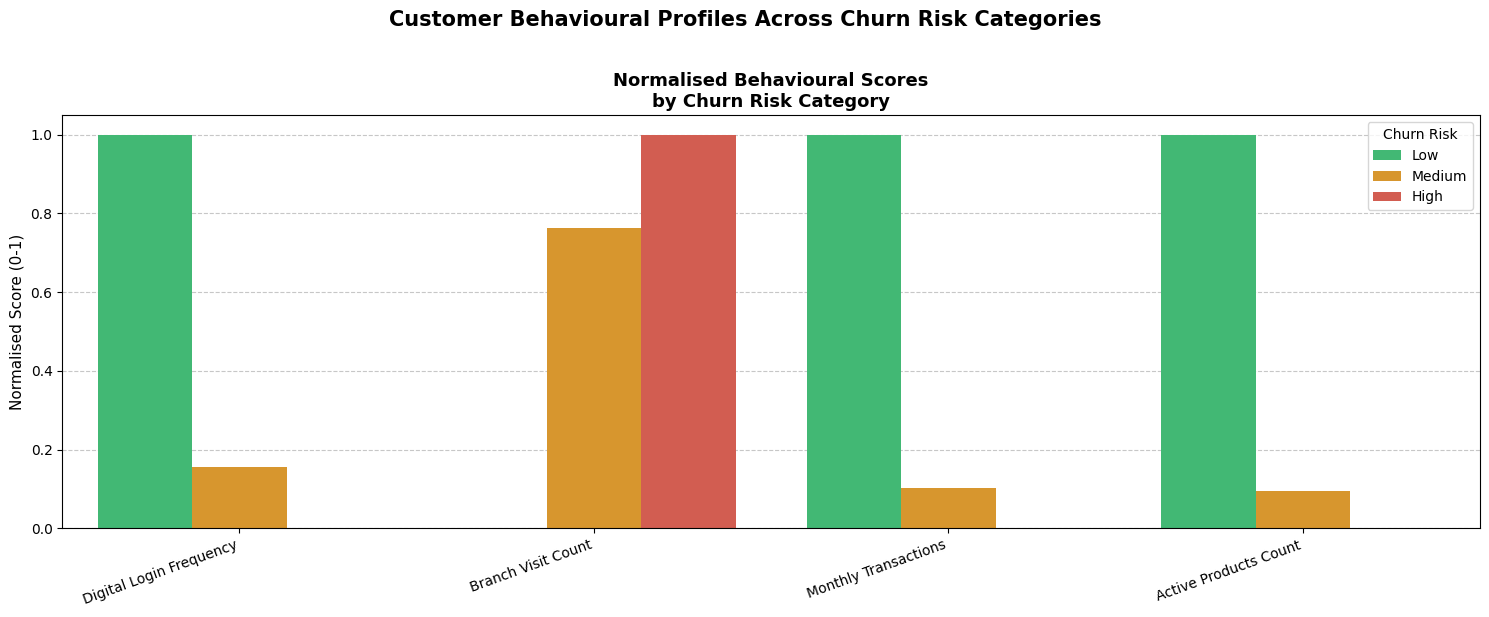

In [98]:
behavioural_cols = [
    'digital_login_frequency',
    'branch_visit_count',
    'monthly_transactions',
    'active_products_count'
]

churn_order  = ["Low", "Medium", "High"]
churn_colors = {"Low": "#2ecc71", "Medium": "#f39c12", "High": "#e74c3c"}

behavioural_profile = (
    df.groupby('churn_risk_label')[behavioural_cols]
    .mean()
    .reindex(churn_order)
)

# Normalise (min-max) each column to 0-1 scale so they're comparable on one chart
#
behavioural_normalised = (behavioural_profile - behavioural_profile.min()) / (
    behavioural_profile.max() - behavioural_profile.min()
)

# Reshape to long format for seaborn
behavioural_long = (
    behavioural_normalised
    .reset_index()
    .melt(id_vars='churn_risk_label', var_name='metric', value_name='normalised_score')
)


behavioural_long['metric'] = (
    behavioural_long['metric']
    .str.replace('_', ' ')
    .str.title()
)

fig, ax = plt.subplots(figsize=(15, 6))


sns.barplot(
    data=behavioural_long,
    x='metric',
    y='normalised_score',
    hue='churn_risk_label',
    hue_order=churn_order,
    palette=churn_colors,
    ax=ax
)
ax.set_title("Normalised Behavioural Scores\nby Churn Risk Category",
                  fontsize=13, fontweight='bold')
ax.set_xlabel("")
ax.set_ylabel("Normalised Score (0-1)", fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')
ax.legend(title="Churn Risk")
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)


plt.suptitle("Customer Behavioural Profiles Across Churn Risk Categories",
             fontsize=15, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

### Credit Score vs Monthly Income by Churn Risk Label

Scatter plot to see relationship between income and credit score, colored by churn risk label. We should see that higher income customers tend to have higher credit scores, and that low churn risk customers are clustered in the high income, high credit score area, while high churn risk customers are more spread out with lower incomes and credit scores.


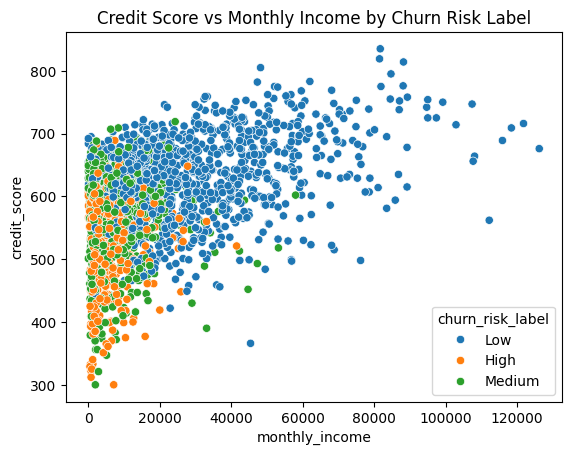

In [99]:
sns.scatterplot(
    x="monthly_income",
    y="credit_score",
    hue="churn_risk_label",
    data=df
)
plt.title("Credit Score vs Monthly Income by Churn Risk Label")
plt.show()


### Churn Risk Category by Loan Utilization Rate Boxplot

Visualize churn risk by loan utilisation rate. We should see a strong correlation where higher loan utilisation rates correspond to higher churn risk categories.

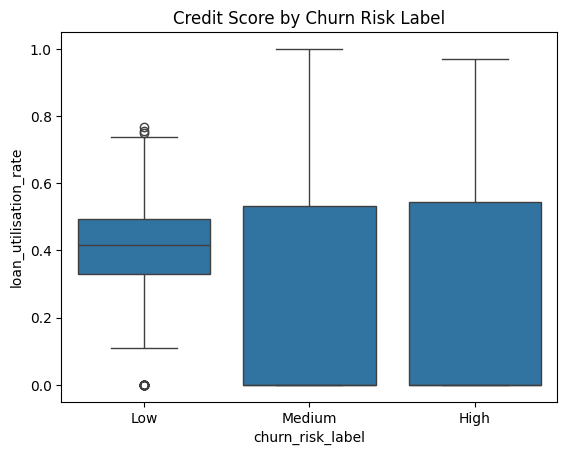

In [100]:
sns.boxplot(x="churn_risk_label", y="loan_utilisation_rate", data=df, order=["Low", "Medium", "High"])
plt.title("Credit Score by Churn Risk Label")
plt.show()

# 3. Customer Segmentation (Clustering)

In this section, we use Machine Learning to segment customers based on profiles.

In [101]:
# import the libraries for clustering

from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings("ignore")

#### Feature Selection

Some of the columns in the data can be excluded for clustering as they are either identifiers, target variables, or not relevant for clustering. These include:
- 'customer_id': This is a unique identifier for each customer and does not contain meaningful information for clustering.
- 'churn_risk_label': This is the target variable we want to predict, so it should not be included in the clustering process.

In [102]:
# Exclude non-feature columns and target variable from clustering
exclude_cols = ['customer_id', 'first_name', 'last_name',
                'churn_risk_label', 'income_band', 
                'preferred_channel']


Some of the categorical columns are relevant for clustering, and they will be encoded, using one-hote encode.

In [103]:
# Define columns to encode
categorical_to_encode = ['gender', 'marital_status', 
                         'education_level', 'employment_status', 'province']

# Create dummy variables for categorical features
df_encoded = pd.get_dummies(df, columns=categorical_to_encode, drop_first=True)
# Removes one dummy column per feature to avoid multicollinearity

In [104]:
# Select features for clustering (exclude identifiers and target variable)
clustering_features = [col for col in df_encoded.columns if col not in exclude_cols]
X = df_encoded[clustering_features]



#### Scale with RobustScaler



###### Different Scaling Methods

1. StandardScaler
- This works well for normally (Gaussian) distributed data but is sensitive to outliers, which we have in our dataset. Transforms each feature to have mean = 0 and std = 1.

2. MinMaxScaler
- This doesn't work well with outliers. It scales each feature to a fixed range using scaled = (value-min)/(max-min).

3. Normalizer
- This will scale each customers instead of each feature so that each customer vector has unit lenth.

3. RobustScaler 
- Uses the median and IQR, making it more robust to outliers and a better choice for our clustering features, as we have a lot of outliers, such as high incomers for monthly income. With RobustScaler, the extreme values do not distort the scaling of other values. 
- scaled = (value-median)/ IQR

In [105]:
# Scale the features using RobustScaler to handle outliers
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

#### Finding the Optimal Number of Clusters

##### 1 . Elbow Method

In the Elbow method, we find the number of k clusters where inertia stops dropping rapidly

In [106]:
inertia_values = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, init='k-means++', n_init=10, max_iter=300)
    # 'kmeans++' initialization helps to improve convergence and cluster quality
    kmeans.fit(X_scaled)
    inertia_values.append(kmeans.inertia_)
    print(f"K={k} | Inertia: {kmeans.inertia_:.2f}")



K=2 | Inertia: 20171.83
K=3 | Inertia: 18225.09
K=4 | Inertia: 17253.28
K=5 | Inertia: 16560.70
K=6 | Inertia: 16004.01
K=7 | Inertia: 15530.78
K=8 | Inertia: 15102.11
K=9 | Inertia: 14752.60
K=10 | Inertia: 14503.02


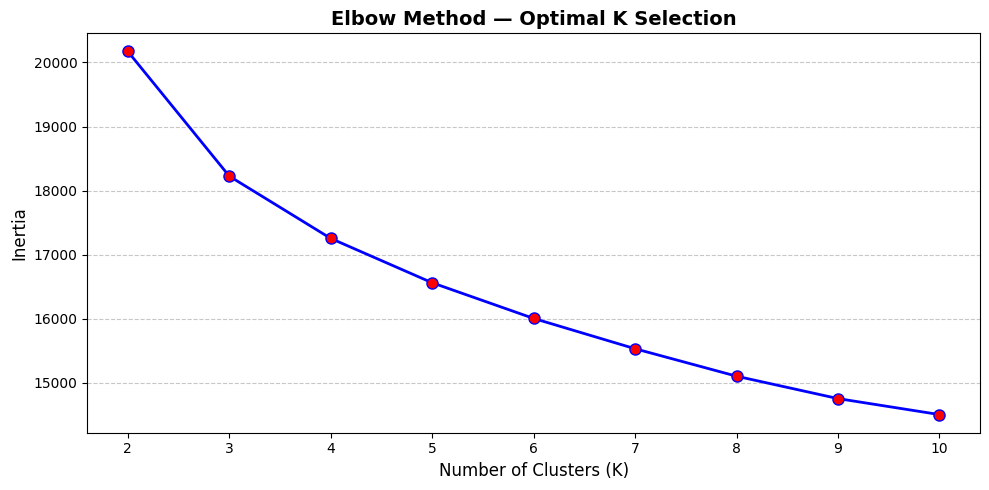

In [107]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(k_range, inertia_values, 'bo-', linewidth=2, markersize=8, markerfacecolor='red')
ax.set_xlabel("Number of Clusters (K)", fontsize=12)
ax.set_ylabel("Inertia", fontsize=12)
ax.set_title("Elbow Method — Optimal K Selection", fontsize=14, fontweight='bold')
ax.set_xticks(list(k_range))
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

##### 2. Silhouette Score

The Silhouette method measures how well a data point fits in the placed cluster. It computes the average distance between the data point and all other data points in the cluster, as well as the average distance between the data point and all other data points in the nearest other cluster. A higher score (-1 to 1) means the data point is well placed in its cluster. 

In [108]:
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, init='k-means++', n_init=10, max_iter=300)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels, sample_size=500,random_state=42)
    silhouette_scores.append(score)
    print(f"K={k} | Silhouette Score: {score:.4f}")

K=2 | Silhouette Score: 0.1600
K=3 | Silhouette Score: 0.1314
K=4 | Silhouette Score: 0.0977
K=5 | Silhouette Score: 0.0946
K=6 | Silhouette Score: 0.0912
K=7 | Silhouette Score: 0.0908
K=8 | Silhouette Score: 0.0859
K=9 | Silhouette Score: 0.0843
K=10 | Silhouette Score: 0.0799


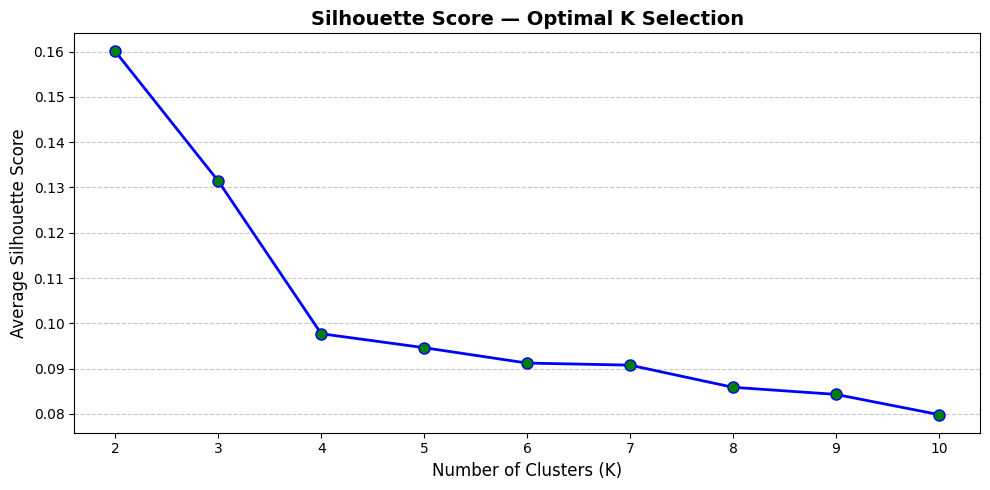

In [109]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(k_range, silhouette_scores, 'bo-', linewidth=2, markersize=8, markerfacecolor='green')
ax.set_xlabel("Number of Clusters (K)", fontsize=12)
ax.set_ylabel("Average Silhouette Score", fontsize=12)
ax.set_title("Silhouette Score — Optimal K Selection", fontsize=14, fontweight='bold')
ax.set_xticks(list(k_range))
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

plt.tight_layout()

plt.show()

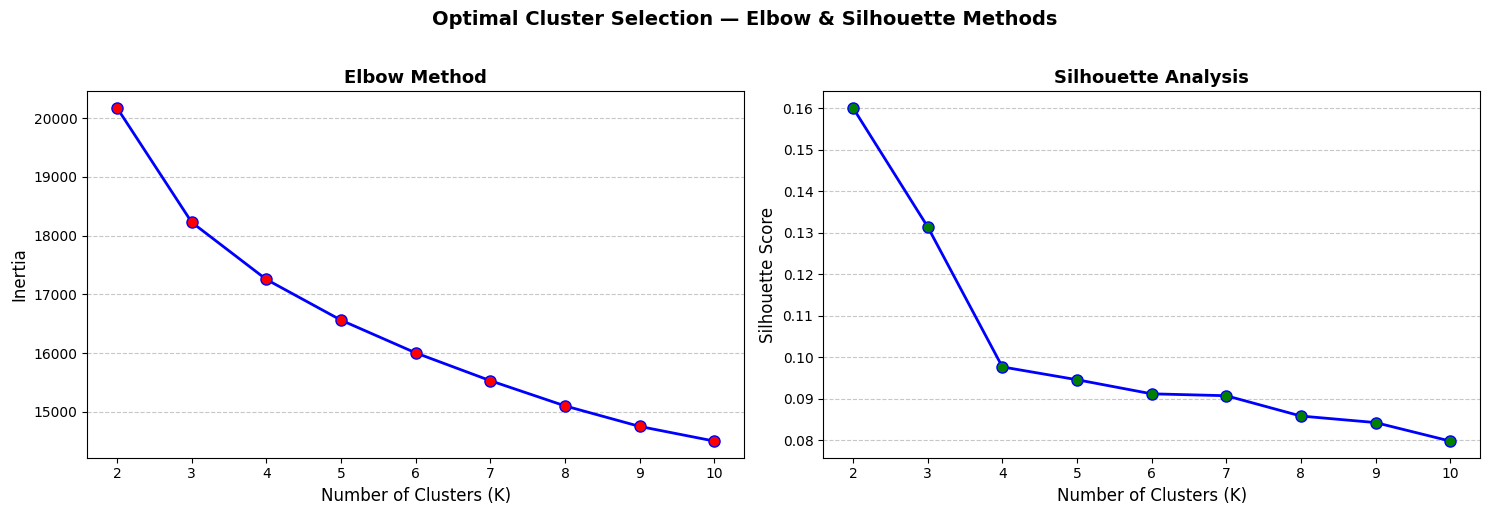

In [110]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Elbow
axes[0].plot(k_range, inertia_values, 'bo-', linewidth=2, 
             markersize=8, markerfacecolor='red')
axes[0].set_xlabel("Number of Clusters (K)", fontsize=12)
axes[0].set_ylabel("Inertia", fontsize=12)
axes[0].set_title("Elbow Method", fontsize=13, fontweight='bold')
axes[0].set_xticks(list(k_range))
axes[0].yaxis.grid(True, linestyle='--', alpha=0.7)
axes[0].set_axisbelow(True)

# Silhouette
axes[1].plot(k_range, silhouette_scores, 'bo-', linewidth=2,
             markersize=8, markerfacecolor='green')
axes[1].set_xlabel("Number of Clusters (K)", fontsize=12)
axes[1].set_ylabel("Silhouette Score", fontsize=12)
axes[1].set_title("Silhouette Analysis", fontsize=13, fontweight='bold')
axes[1].set_xticks(list(k_range))
axes[1].yaxis.grid(True, linestyle='--', alpha=0.7)
axes[1].set_axisbelow(True)

plt.suptitle("Optimal Cluster Selection — Elbow & Silhouette Methods",
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

##### Interpreting the Results

The elbow method indicates that there is a sharp curve around K = 3 and K = 4. This could be out optimal number of clusters. However, we have to check the Silhouette scores and confirm if the two methods are in agreement. From the scores, the highest score is 0.16 for K = 2. This is considered very weak, reflecting that there is no structure found in the data. This could be due to the high dimensionality of the data. We have 42 features. It could also be a result of the one-hot encoded features.

To deal with this, we will try Principal Component Analysis (PCA) first. This basically projects the data into smaller number of dimensions and capture the most important and relevant information.

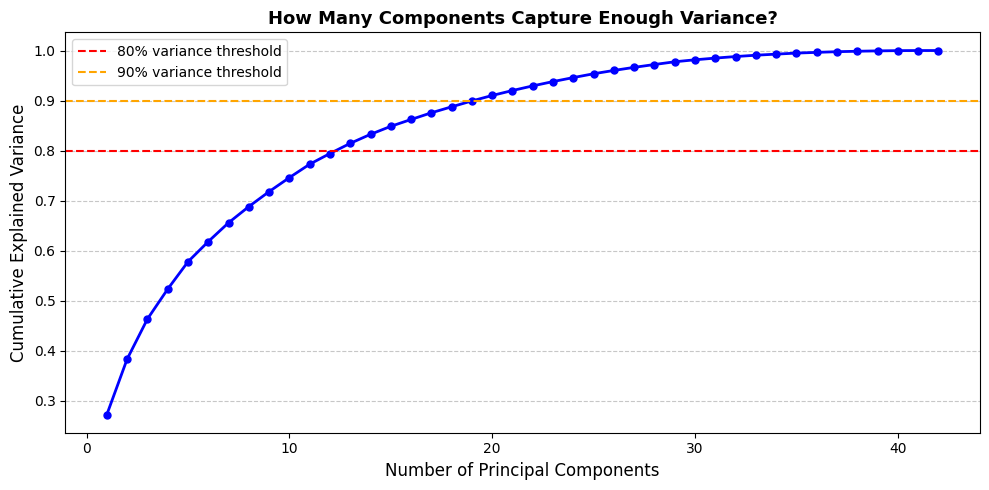

80% variance captured by 13 components
85% variance captured by 16 components
90% variance captured by 20 components


In [111]:
# PCA

from sklearn.decomposition import PCA

pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)

# Plot cumulative explained variance
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 
        'bo-', linewidth=2, markersize=5)
ax.axhline(y=0.80, color='red',    linestyle='--', label='80% variance threshold')
ax.axhline(y=0.90, color='orange', linestyle='--', label='90% variance threshold')
ax.set_xlabel("Number of Principal Components", fontsize=12)
ax.set_ylabel("Cumulative Explained Variance", fontsize=12)
ax.set_title("How Many Components Capture Enough Variance?", 
             fontsize=13, fontweight='bold')
ax.legend()
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()


for threshold in [0.80, 0.85, 0.90]:
    n_components = np.argmax(cumulative_variance >= threshold) + 1
    print(f"{threshold*100:.0f}% variance captured by {n_components} components")

In [112]:
# Apply PCA with chosen components
N_COMPONENTS = 15 

pca = PCA(n_components=N_COMPONENTS, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"Variance retained: {pca.explained_variance_ratio_.sum()*100:.1f}%")

Variance retained: 84.8%


Initial clustering on 42 features produced low silhouette scores , likely due to the high-dimensionality.

PCA was applied to reduce the feature space while retaining meaningful variance:
- Original dimensions: 42
- Retained dimensions: 15  
- Variance retained: ~85%

This reduction removes dimensional noise while 
preserving the dominant financial, behavioural and risk signals. 

We repeat the elbow and silhouette analysis on the PCA-transformed data.

K= 2 | Inertia:   16456.28 | Silhouette: 0.1828
K= 3 | Inertia:   14518.97 | Silhouette: 0.1572
K= 4 | Inertia:   13544.00 | Silhouette: 0.1198
K= 5 | Inertia:   12857.19 | Silhouette: 0.1173
K= 6 | Inertia:   12305.94 | Silhouette: 0.1161
K= 7 | Inertia:   11835.14 | Silhouette: 0.1154
K= 8 | Inertia:   11447.24 | Silhouette: 0.1082
K= 9 | Inertia:   11102.33 | Silhouette: 0.1033
K=10 | Inertia:   10838.18 | Silhouette: 0.1026
K=11 | Inertia:   10606.90 | Silhouette: 0.0933


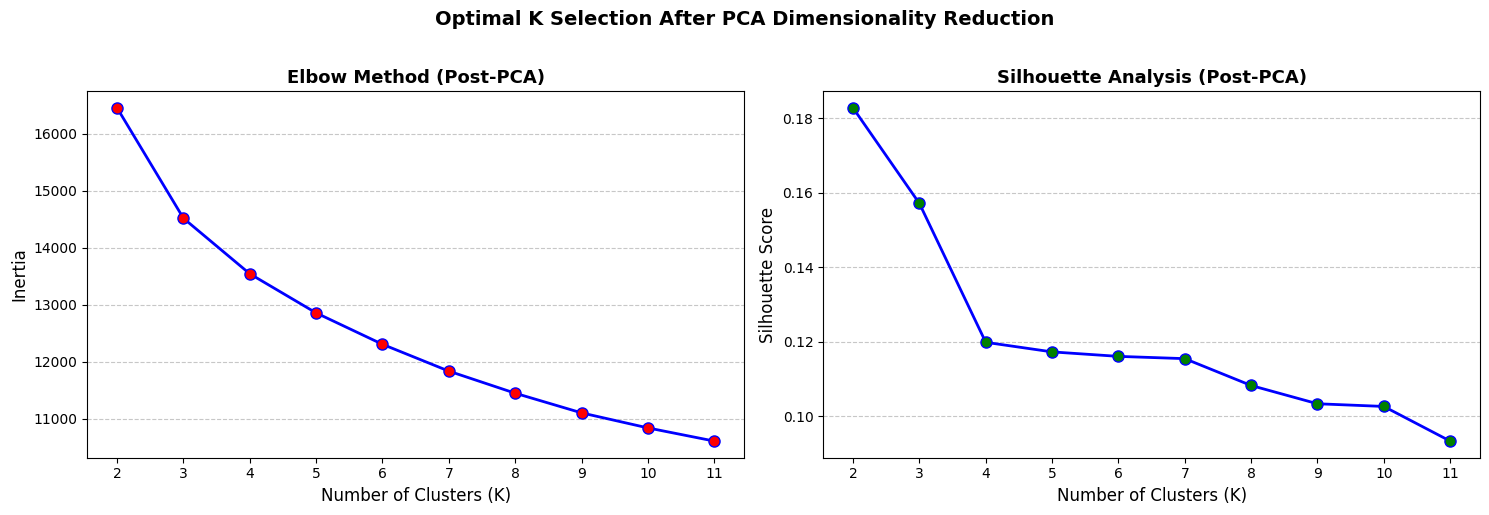

In [113]:

inertia_pca     = []
silhouette_pca  = []
k_range         = range(2, 12)

for k in k_range:
    kmeans = KMeans(
        n_clusters=k,
        init='k-means++',
        n_init=10,
        random_state=42,
        max_iter=300
    )
    labels = kmeans.fit_predict(X_pca)
    inertia_pca.append(kmeans.inertia_)
    score = silhouette_score(X_pca, labels, sample_size=500, random_state=42)
    silhouette_pca.append(score)
    print(f"K={k:2d} | Inertia: {kmeans.inertia_:>10.2f} | Silhouette: {score:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(k_range, inertia_pca, 'bo-', linewidth=2,
             markersize=8, markerfacecolor='red')
axes[0].set_xlabel("Number of Clusters (K)", fontsize=12)
axes[0].set_ylabel("Inertia", fontsize=12)
axes[0].set_title("Elbow Method (Post-PCA)", fontsize=13, fontweight='bold')
axes[0].set_xticks(list(k_range))
axes[0].yaxis.grid(True, linestyle='--', alpha=0.7)
axes[0].set_axisbelow(True)

axes[1].plot(k_range, silhouette_pca, 'bo-', linewidth=2,
             markersize=8, markerfacecolor='green')
axes[1].set_xlabel("Number of Clusters (K)", fontsize=12)
axes[1].set_ylabel("Silhouette Score", fontsize=12)
axes[1].set_title("Silhouette Analysis (Post-PCA)", fontsize=13, fontweight='bold')
axes[1].set_xticks(list(k_range))
axes[1].yaxis.grid(True, linestyle='--', alpha=0.7)
axes[1].set_axisbelow(True)

plt.suptitle("Optimal K Selection After PCA Dimensionality Reduction",
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

##### Interpreting the Results

Both the Elbow method and Silhouette method were applied across K=2 to K=11 with the original 42 features, and again after PCA dimensionality reduction with 15 features. The goal was to get a silhouette score of at least 0.25, as this is generally considered good enough to have structure in the data. With PCA dimensionality reduction, the silhouette scores marginally increased but remained well below 0.25, indicating overlapping customer clusters.

##### Choosing the optimal K

From the Elbow method, the elbow point is around K=3 or K=4. From the Silhouette method, the optimal K is K=2, with the highest score. There is no agreement between these two methods, therefore, we will choose K based on good business practice.

K=2 only gives two clusters, this will only divide customers into two groups, good or bad, financially healthy or unhealthy, etc. This is not interesting. 

K=3 gives 3 clusters. This is better but the recommendation engine will work better with at least 4 distinct clusters to generate differentiated suggestions. Hence we choose 4 clusters as our optimal number of clusters. 



##### Fitting the Final Model


In [114]:
# Final KMeans with optimal K on PCA-reduced data
OPTIMAL_K = 4

kmeans_final = KMeans(n_clusters=OPTIMAL_K, random_state=42, 
                      init='k-means++', n_init=10, max_iter=300)
final_labels = kmeans_final.fit_predict(X_pca)
df['cluster'] = final_labels

In [115]:
# Analyze cluster characteristics
cluster_counts = df['cluster'].value_counts().sort_index()
print("Cluster Counts:")
print(cluster_counts)
print(f"\nSmallest cluster has {cluster_counts.min()} customers, largest has {cluster_counts.max()} customers")

Cluster Counts:
cluster
0    639
1    320
2    409
3    632
Name: count, dtype: int64

Smallest cluster has 320 customers, largest has 639 customers


We have 4 distinct clusters, with a satisfying distribution of customers in each cluster.


#### Cluster Profiling

We have 4 distinct clusters of customers, but they are meaningless because they are not profiled. As of now, its just cluster 1,2,3,4. Now we can profile each cluster so that each cluster has customers who share the same characteristics. 

In [116]:
# Profile clusters based on key features. Use original data, unscaled and with categorical features in their original form for interpretability.

profile_features = [
    # Financial features
    'monthly_income', 'savings_rate', 'account_tenure_years',
    # Risk features
    'credit_score', 'loan_utilisation_rate', 'late_payment_count',
    'has_ever_defaulted',
    # Behavioural features
    'digital_login_frequency', 'branch_visit_count',
    'monthly_transactions', 'avg_transaction_value',
    # Product features
    'active_products_count', 'has_credit_card', 'has_home_loan',
    'has_personal_loan', 'has_vehicle_finance', 'has_investment_account',
    # Target feature
    'churn_risk_label'
] 

# Mean of numerical features per cluster
cluster_profile = df.groupby('cluster')[profile_features[:-1]].mean().round(3)


In [117]:
# Cluster Profile
cluster_profile

,monthly_income,savings_rate,account_tenure_years,credit_score,loan_utilisation_rate,late_payment_count,has_ever_defaulted,digital_login_frequency,branch_visit_count,monthly_transactions,avg_transaction_value,active_products_count,has_credit_card,has_home_loan,has_personal_loan,has_vehicle_finance,has_investment_account
cluster,,,,,,,,,,,,,,,,,
0,22247.081,0.384,6.010,604.873,0.440,1.692,0.581,14.731,3.355,24.654,645.834,3.322,0.679,0.419,0.535,0.538,0.161
1,55225.181,0.397,8.415,666.003,0.384,1.447,0.406,18.197,3.112,47.044,731.582,4.741,0.916,0.850,0.597,0.747,0.631
2,4371.188,0.049,5.029,489.191,0.294,4.103,0.831,12.438,3.817,13.064,389.500,1.264,0.191,0.044,0.227,0.073,0.002
3,6944.585,0.370,5.124,590.843,0.213,1.426,0.589,12.057,3.891,15.062,351.815,1.394,0.210,0.044,0.214,0.095,0.014


In [148]:
# Find the most common churn risk label per cluster
cluster_profile['dominant_churn_risk'] = (
    df.groupby('cluster')['churn_risk_label']
    .agg(lambda x: x.value_counts().index[0])
)

# cluster size
cluster_profile['cluster_size'] = df['cluster'].value_counts().sort_index()

print(cluster_profile.T)  # Transpose for better readability

cluster                          0          1         2         3
monthly_income           22247.081  55225.181  4371.188  6944.585
savings_rate                 0.384      0.397     0.049      0.37
account_tenure_years          6.01      8.415     5.029     5.124
credit_score               604.873    666.003   489.191   590.843
loan_utilisation_rate         0.44      0.384     0.294     0.213
late_payment_count           1.692      1.447     4.103     1.426
has_ever_defaulted           0.581      0.406     0.831     0.589
digital_login_frequency     14.731     18.197    12.438    12.057
branch_visit_count           3.355      3.112     3.817     3.891
monthly_transactions        24.654     47.044    13.064    15.062
avg_transaction_value      645.834    731.582     389.5   351.815
active_products_count        3.322      4.741     1.264     1.394
has_credit_card              0.679      0.916     0.191      0.21
has_home_loan                0.419       0.85     0.044     0.044
has_person

##### Visualize the Profiles of the Clusters

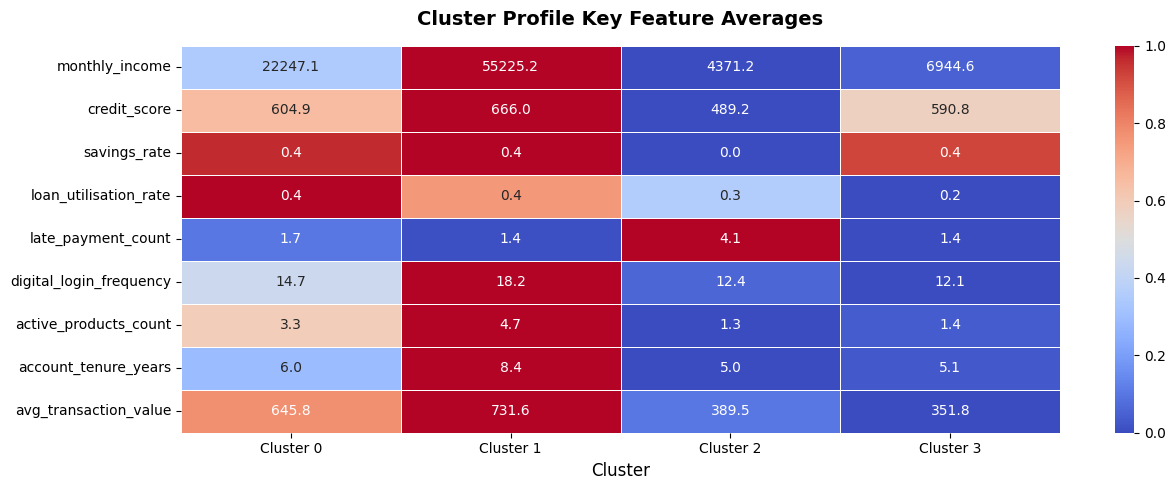

In [120]:
heatmap_features = [
    'monthly_income', 'credit_score', 'savings_rate',
    'loan_utilisation_rate', 'late_payment_count',
    'digital_login_frequency', 'active_products_count',
    'account_tenure_years', 'avg_transaction_value'
]

# Normalise profile values to 0-1 for visualization
profile_heatmap = cluster_profile[heatmap_features].copy()
profile_normalised = (profile_heatmap - profile_heatmap.min()) / (
    profile_heatmap.max() - profile_heatmap.min()
)

fig, ax = plt.subplots(figsize=(13, 5))

sns.heatmap(
    profile_normalised.T,       # Transpose 
    annot=cluster_profile[heatmap_features].T,  # Show actual values not normalised
    fmt=".1f",
    cmap="coolwarm",
    linewidths=0.5,
    ax=ax
)

ax.set_title("Cluster Profile Key Feature Averages",
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Cluster", fontsize=12)
ax.set_ylabel("")
ax.set_xticklabels([f"Cluster {i}" for i in range(OPTIMAL_K)], rotation=0)

plt.tight_layout()
plt.show()

##### Visualize Cluster Distribution

Visualize the cluster distribution for key features using histograms to understand the spread and central tendencies of each feature within clusters.

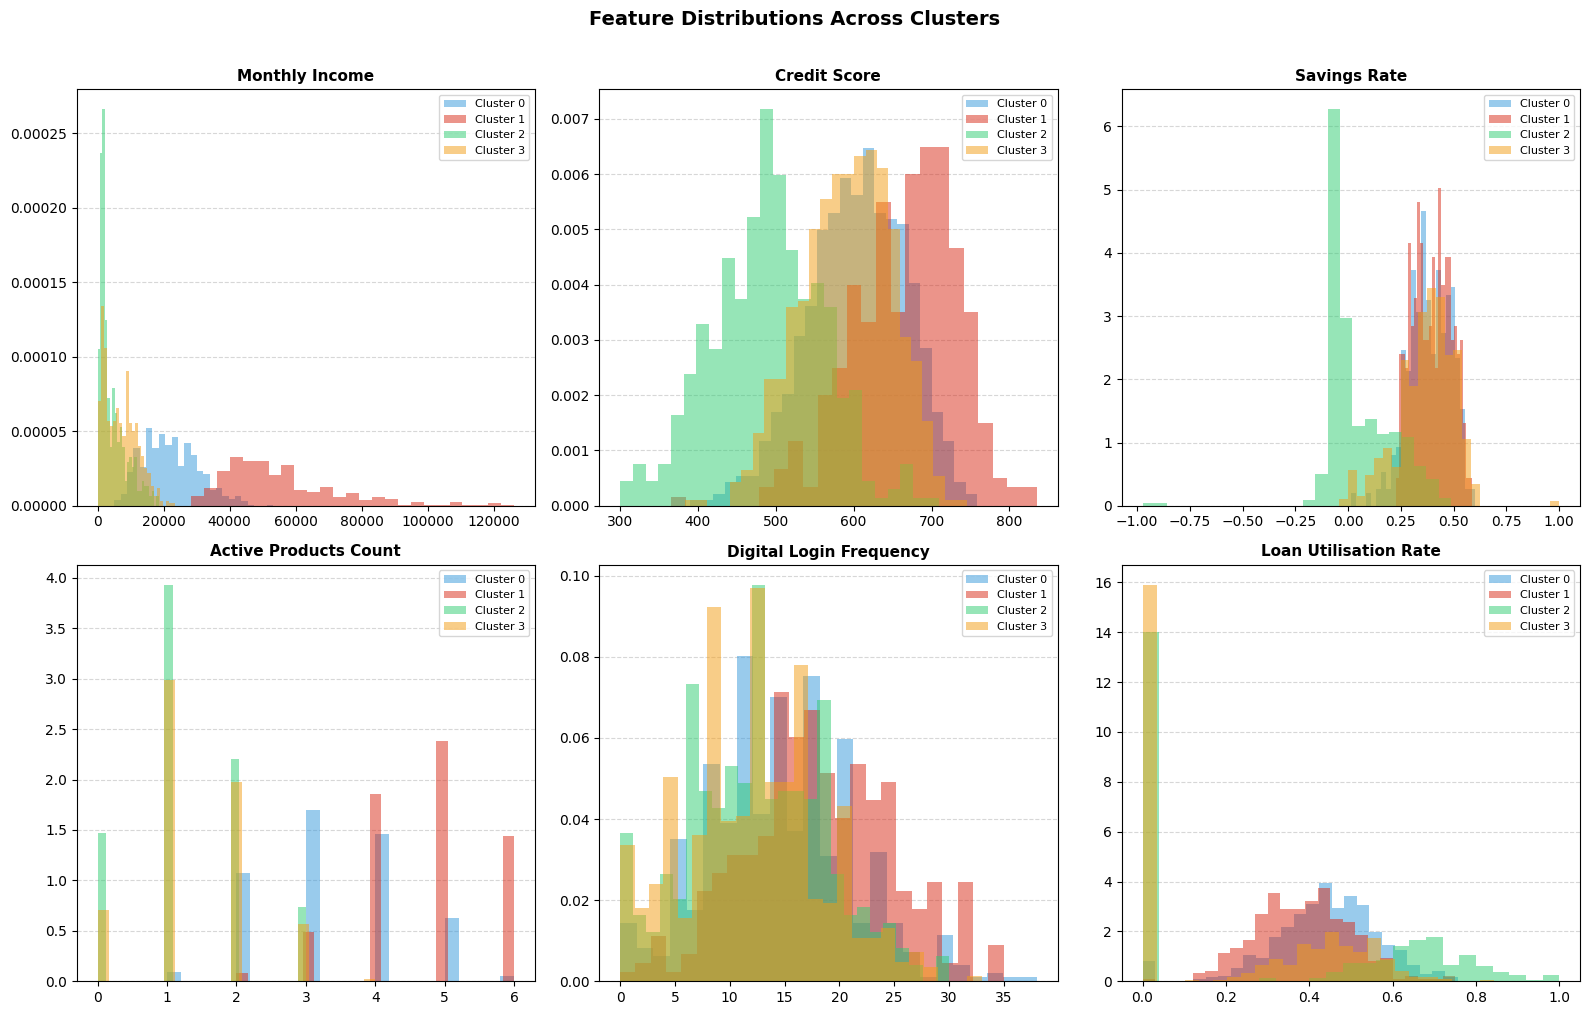

In [121]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

distribution_features = [
    'monthly_income', 'credit_score', 'savings_rate',
    'active_products_count', 'digital_login_frequency', 'loan_utilisation_rate'
]

cluster_palette = {0: "#3498db", 1: "#d82a17", 2: "#2ecc71", 3: "#f39c12"}

for idx, feature in enumerate(distribution_features):
    for cluster_id in range(OPTIMAL_K):
        cluster_data = df[df['cluster'] == cluster_id][feature]
        axes[idx].hist(
            cluster_data,
            bins=25,
            alpha=0.5,
            label=f"Cluster {cluster_id}",
            color=cluster_palette[cluster_id],
            density=True        # Normalise so clusters of different sizes are comparable
        )
    axes[idx].set_title(feature.replace('_', ' ').title(), fontsize=11, fontweight='bold')
    axes[idx].set_xlabel("")
    axes[idx].legend(fontsize=8)
    axes[idx].yaxis.grid(True, linestyle='--', alpha=0.5)
    axes[idx].set_axisbelow(True)

plt.suptitle("Feature Distributions Across Clusters",
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

The cluster distributions show the overlapping nature of the clusters, however, we can still see some differences in the shapes and peaks of the distributions which indicate that the clusters do have distinct characteristics, even if they are not perfectly separated.

##### Visualize In 2D using PCA Components

The clusters exist in 42 dimensions. As we noted above, the separation between the clusters is not perfect, and hardly visible. However, if we project the clusters into the first 2 of the components from our PCA, we can plot a scatter plot of the clusters that can clearly show the clusters and their separations. We can also plot other components other than the first two to study the separations.

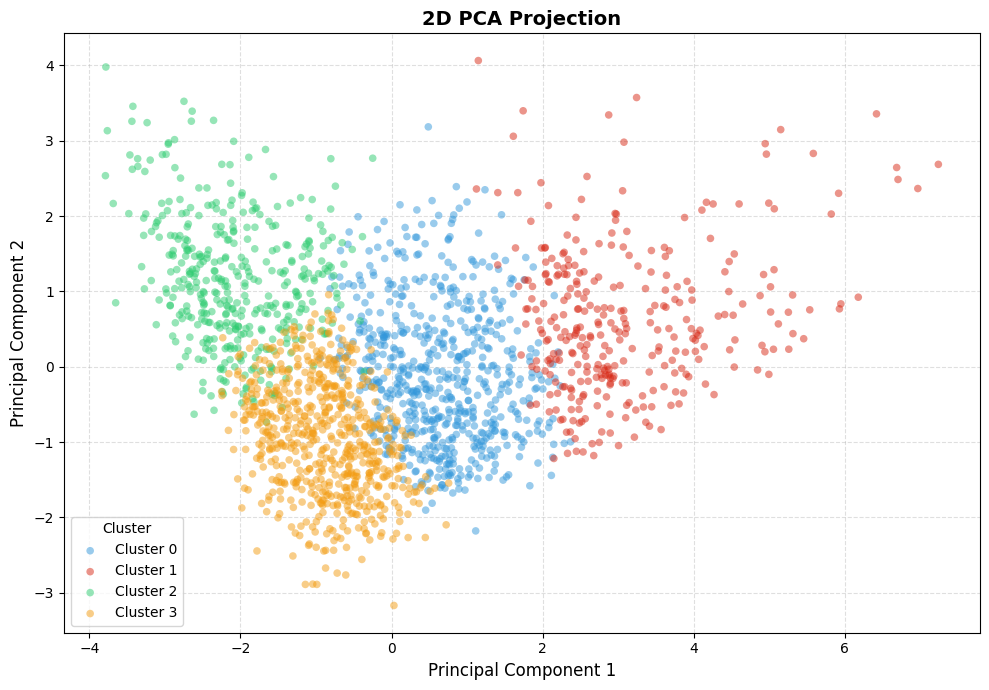

In [133]:
fig, ax = plt.subplots(figsize=(10, 7))

for cluster_id in range(OPTIMAL_K):
    mask = df['cluster'] == cluster_id
    ax.scatter(
        X_pca[mask, 0],         # First principal component
        X_pca[mask, 1],         # Second principal component
        c=cluster_palette[cluster_id],
        label=f"Cluster {cluster_id}",
        alpha=0.5,
        s=30,
        edgecolors='none'
    )

ax.set_xlabel("Principal Component 1", fontsize=12)
ax.set_ylabel("Principal Component 2", fontsize=12)
ax.set_title("2D PCA Projection",
             fontsize=14, fontweight='bold')
ax.legend(title="Cluster", fontsize=10)
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.xaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

##### Naming the Clusters Based on Cluster Characteristics

Four distinct customer segments were identified through KMeans clustering 
on PCA-reduced features.

**Cluster 0 — Stable Middles:** Middle-income, stable financial 
behaviour, moderate product engagement. Core retail banking segment.

**Cluster 1 — Premium Loyalists:** Highest income, credit score, 
product depth and tenure. The bank's most valuable segment.

**Cluster 2 — Financially Vulnerable:** Lowest income and credit 
score, zero savings, highest late payment count. Requires financial 
wellness intervention.

**Cluster 3 — Emerging Potentials:** Low income but financially 
disciplined, good savings rate and low loan utilisation. Underserved 
growth opportunity.



In [134]:
cluster_names = {
    0: "Stable Middles",
    1: "Premium Loyalists",
    2: "Financially Vulnerable",
    3: "Emerging Potentials"
}

df['cluster_name'] = df['cluster'].map(cluster_names)
print(df['cluster_name'].value_counts())

cluster_name
Stable Middles            639
Emerging Potentials       632
Financially Vulnerable    409
Premium Loyalists         320
Name: count, dtype: int64


# 4. Recommendation Engine

In this section, we build the product recommendation engine. The engine will be needs-based recommendation. 

##### Define the Bank's Product Catalogue

Each product has:
- description
- min_income: minimum monthly income required
- min_credit_score: minimum credit score required  
- target_segments: which cluster names this product suits
- existing_column: the column in df that tracks current ownership (None if new)

In [167]:
product_catalogue = {
    "Credit Card": {
        "description": "Revolving credit facility for everyday purchases",
        "min_income": 6000,
        "min_credit_score": 580,
        "target_segments": ["Stable Middles", "Premium Loyalists", "Emerging Potentials"],
        "existing_column": "has_credit_card"
    },
    "Home Loan": {
        "description": "Long-term mortgage for property purchase",
        "min_income": 20000,
        "min_credit_score": 620,
        "target_segments": ["Stable Middles", "Premium Loyalists"],
        "existing_column": "has_home_loan"
    },
    "Vehicle Finance": {
        "description": "Installment finance for vehicle purchase",
        "min_income": 12000,
        "min_credit_score": 580,
        "target_segments": ["Stable Middles", "Premium Loyalists", "Emerging Potentials"],
        "existing_column": "has_vehicle_finance"
    },
    "Personal Loan": {
        "description": "Unsecured loan for personal expenses",
        "min_income": 6000,
        "min_credit_score": 550,
        "target_segments": ["Stable Middles", "Emerging Potentials"],
        "existing_column": "has_personal_loan"
    },
    "Investment Account": {
        "description": "Unit trust or fixed investment for wealth accumulation",
        "min_income": 25000,
        "min_credit_score": 620,
        "target_segments": ["Premium Loyalists", "Stable Middles"],
        "existing_column": "has_investment_account"
    },
    "Fixed Deposit": {
        "description": "Guaranteed return savings over a fixed term",
        "min_income": 6000,
        "min_credit_score": 500,
        "target_segments": ["Emerging Potentials", "Stable Middles", "Premium Loyalists"],
        "existing_column": None  # New product
    },
    "Overdraft Facility": {
        "description": "Short-term credit buffer linked to cheque account",
        "min_income": 6000,
        "min_credit_score": 560,
        "target_segments": ["Stable Middles", "Emerging Potentials"],
        "existing_column": None  # New product
    },
    "Revolving Credit": {
        "description": "Flexible credit facility that replenishes as you repay",
        "min_income": 10000,
        "min_credit_score": 570,
        "target_segments": ["Stable Middles", "Premium Loyalists"],
        "existing_column": None  # New product
    },
    "Rewards Programme": {
        "description": "Points-based loyalty programme with lifestyle benefits",
        "min_income": 15000,
        "min_credit_score": 580,
        "target_segments": ["Premium Loyalists", "Stable Middles"],
        "existing_column": None  # New product
    },
    "Financial Wellness Plan": {
        "description": "Debt counselling and budgeting support programme",
        "min_income": 0,      
        "min_credit_score": 0, 
        "target_segments": ["Financially Vulnerable"],
        "existing_column": None
    },
    "Youth Savings Accoutn": {
        "description": "Entry level savings account with goal-based features for new earners",
        "min_income": 3000,
        "min_credit_score": 0,
        "target_segments": ["Emerging Potentials"],
        "existing_column": None

    }
}


##### Compute Ownership Rate per Cluster

In [168]:
# compute ownership rates for products that exist in the data, by cluster
tracked_products = {
    name: details for name, details in product_catalogue.items()
    if details['existing_column'] is not None
}

# ownership rate table
ownership_rates = {}
for product_name, details in tracked_products.items():
    col = details['existing_column']
    rates = df.groupby('cluster_name')[col].mean().mul(100).round(1)
    ownership_rates[product_name] = rates

ownership_df = pd.DataFrame(ownership_rates)
print("\nProduct Ownership Rates by Cluster (%):")
print(ownership_df.to_string())


Product Ownership Rates by Cluster (%):
                        Credit Card  Home Loan  Vehicle Finance  Personal Loan  Investment Account
cluster_name                                                                                      
Emerging Potentials            21.0        4.4              9.5           21.4                 1.4
Financially Vulnerable         19.1        4.4              7.3           22.7                 0.2
Premium Loyalists              91.6       85.0             74.7           59.7                63.1
Stable Middles                 67.9       41.9             53.8           53.5                16.1


##### Recommendation Logic

The recommendation engine applies a three-stage filtering and scoring 
approach designed to balance financial responsibility with business growth.

- Segment Eligibility Filter - Each product in the catalogue defines which customer segments it is 
appropriate for, based on the segment's financial profile and life stage. 


- Financial Eligibility Filter - Each product defines minimum income and credit score thresholds.

- Ownership Gap Scoring - Among eligible products, priority is given to products with the lowest 
current ownership rate in that cluster, the largest untapped opportunity. 

For new products not currently tracked in the dataset, an ownership rate of 0 
is assigned, reflecting maximum opportunity. Products are ranked by gap 
score (gapscore = 1-ownership rate) descending, and the top 3 are selected.


In [170]:
def recommend_products_for_cluster(cluster_name, cluster_profile_row, top_n=3):
    
    """
    Recommends top N products for a given cluster based on:
    - Segment eligibility
    - Financial eligibility
    - Ownership gap
    
    Parameters
    ----------
    cluster_name: str
                - name of the cluster
    cluster_profile_row: Series 
                        - mean feature values for this cluster
    top_n: int   
        — number of products to recommend
    
    Returns
    -------
    List of recommended product names with reasoning
    """
    avg_income       = cluster_profile_row['monthly_income']
    avg_credit_score = cluster_profile_row['credit_score']
    
    recommendations = []
    
    for product_name, details in product_catalogue.items():
        
        # Don't do anything if the product isn't targeted at this segment
        if cluster_name not in details['target_segments']:
            continue
        
        # Don't do anything if the cluster doesn't meet the financial eligibility criteria
        if avg_income < details['min_income']:
            continue

        # Don't do anything if the cluster doesn't meet the credit score eligibility criteria
        if avg_credit_score < details['min_credit_score']:
            continue
        
        # Compute ownership gap score for products that exist in the data. 
        # For new products, we assume maximum gap (1.0) since no one has it yet.
        if details['existing_column'] is not None:
            col = details['existing_column']
            ownership_rate = df[df['cluster_name'] == cluster_name][col].mean()
            gap_score = 1 - ownership_rate 
        else:
            gap_score = 1.0 # Max gap for new products
        
        recommendations.append({
            'product': product_name,
            'description': details['description'],
            'gap_score': round(gap_score, 3),
            'ownership_rate': round((ownership_rate) * 100, 1) if details['existing_column'] else 0.0
        })
    
    # Sort by gap score descending — biggest opportunity first
    recommendations = sorted(recommendations, key=lambda x: x['gap_score'], reverse=True)
    
    return recommendations[:top_n]


# ── Generate Recommendations For All Clusters ──────────────────────────────────
print("=" * 65)
print("PRODUCT RECOMMENDATIONS BY CUSTOMER SEGMENT")
print("=" * 65)

cluster_recommendations = {}

for cluster_id in range(OPTIMAL_K):
    cluster_name = cluster_names[cluster_id]
    profile_row  = cluster_profile.loc[cluster_id]
    recs         = recommend_products_for_cluster(cluster_name, profile_row, top_n=3)
    cluster_recommendations[cluster_name] = recs
    
    print(f"\n{'─' * 65}")
    print(f"  {cluster_name.upper()}")
    print(f"  Avg Income: R{profile_row['monthly_income']:,.0f} | "
          f"Credit Score: {profile_row['credit_score']:.0f} | "
          f"Products Held: {profile_row['active_products_count']:.1f}")
    print(f"{'─' * 65}")
    
    for i, rec in enumerate(recs, 1):
        ownership_str = (f"Current ownership: {rec['ownership_rate']:.0f}%"
                        if rec['ownership_rate'] > 0 else "New product offering")
        print(f"  {i}. {rec['product']}")
        print(f"     → {rec['description']}")
        print(f"     → {ownership_str} | Gap score: {rec['gap_score']:.3f}")

print(f"\n{'=' * 65}")

PRODUCT RECOMMENDATIONS BY CUSTOMER SEGMENT

─────────────────────────────────────────────────────────────────
  STABLE MIDDLES
  Avg Income: R22,247 | Credit Score: 605 | Products Held: 3.3
─────────────────────────────────────────────────────────────────
  1. Fixed Deposit
     → Guaranteed return savings over a fixed term
     → New product offering | Gap score: 1.000
  2. Overdraft Facility
     → Short-term credit buffer linked to cheque account
     → New product offering | Gap score: 1.000
  3. Revolving Credit
     → Flexible credit facility that replenishes as you repay
     → New product offering | Gap score: 1.000

─────────────────────────────────────────────────────────────────
  PREMIUM LOYALISTS
  Avg Income: R55,225 | Credit Score: 666 | Products Held: 4.7
─────────────────────────────────────────────────────────────────
  1. Fixed Deposit
     → Guaranteed return savings over a fixed term
     → New product offering | Gap score: 1.000
  2. Revolving Credit
     → Flexi

##### Visualize the Recommendations


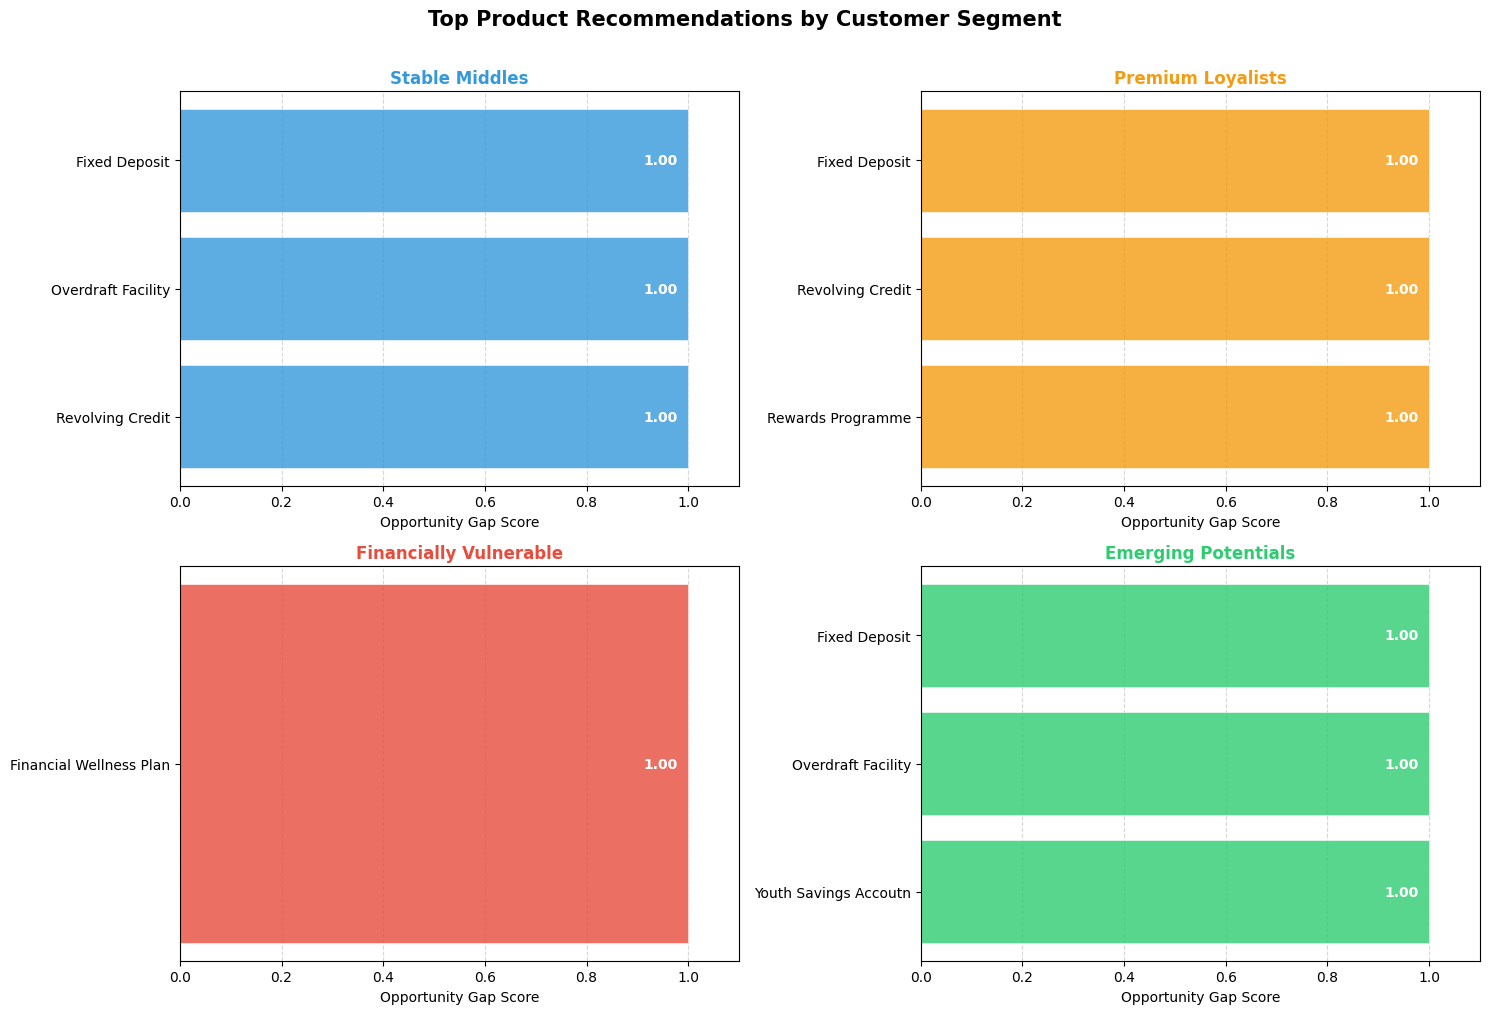

In [171]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

cluster_colors = {
    "Stable Middles":        "#3498db",
    "Premium Loyalists":     "#f39c12",
    "Financially Vulnerable":"#e74c3c",
    "Emerging Potentials":   "#2ecc71"
}

for idx, (cluster_name, recs) in enumerate(cluster_recommendations.items()):
    products    = [r['product'] for r in recs]
    gap_scores  = [r['gap_score'] for r in recs]
    color       = cluster_colors[cluster_name]
    
    bars = axes[idx].barh(
        products, gap_scores,
        color=color, alpha=0.8, edgecolor='white', linewidth=0.5
    )
    
    # Add gap score labels on bars
    for bar, score in zip(bars, gap_scores):
        axes[idx].text(
            bar.get_width() - 0.02,
            bar.get_y() + bar.get_height() / 2,
            f'{score:.2f}',
            va='center', ha='right',
            color='white', fontweight='bold', fontsize=10
        )
    
    axes[idx].set_title(cluster_name, fontsize=12, fontweight='bold', color=color)
    axes[idx].set_xlabel("Opportunity Gap Score", fontsize=10)
    axes[idx].set_xlim(0, 1.1)
    axes[idx].xaxis.grid(True, linestyle='--', alpha=0.5)
    axes[idx].set_axisbelow(True)
    axes[idx].invert_yaxis()  # Highest gap at top

plt.suptitle("Top Product Recommendations by Customer Segment",
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

##### Results Summary

The recommendation engine produced differentiated, segment-appropriate 
product suggestions across all four customer clusters.

**Financially Vulnerable:** A single recommendation — Financial Wellness 
Plan — indicates an intentional decision to prioritise customer financial 
stability over revenue generation. Recommending credit products to this 
segment would be irresponsible.

**Emerging Potentials:** Entry-level products (Fixed Deposit, Overdraft, 
Youth Savings Account) designed to deepen the banking relationship with 
a financially disciplined but underserved segment.

**Stable Middles:** Mid-tier credit and savings products (Fixed Deposit, 
Overdraft, Revolving Credit) targeting the product ownership gap in a 
reliable, creditworthy segment. 

**Premium Loyalists:** Premium products (Fixed Deposit, Revolving Credit, 
Rewards Programme) that reward loyalty and support wealth management 
goals. 



##### Predict Cluster and Recommendations for New Customers

Here we train a classifier (RandomForestClassifier) to predict cluster from original features, allowing us to assign new customers without re-running KMeans, or clustering.

Use the same features as clustering for prediction but without PCA, but scaled,for normality.


In [156]:
# Train a classifier to predict cluster membership
from sklearn.ensemble import RandomForestClassifier

feature_cols = [col for col in df_encoded.columns if col not in exclude_cols]

X_train  = df_encoded[feature_cols]
y_train  = df['cluster']

classifier = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced' 
)
classifier.fit(X_train, y_train)

# print(f"Classifier trained on {len(X_train)} customers")
# print(f"Training accuracy: {classifier.score(X_train, y_train):.3f}")


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

Check the features that are most important for distinguishing between the clusters according to the model. This can help us understand what drives cluster membership and validate that the model is picking up on meaningful patterns in the data.


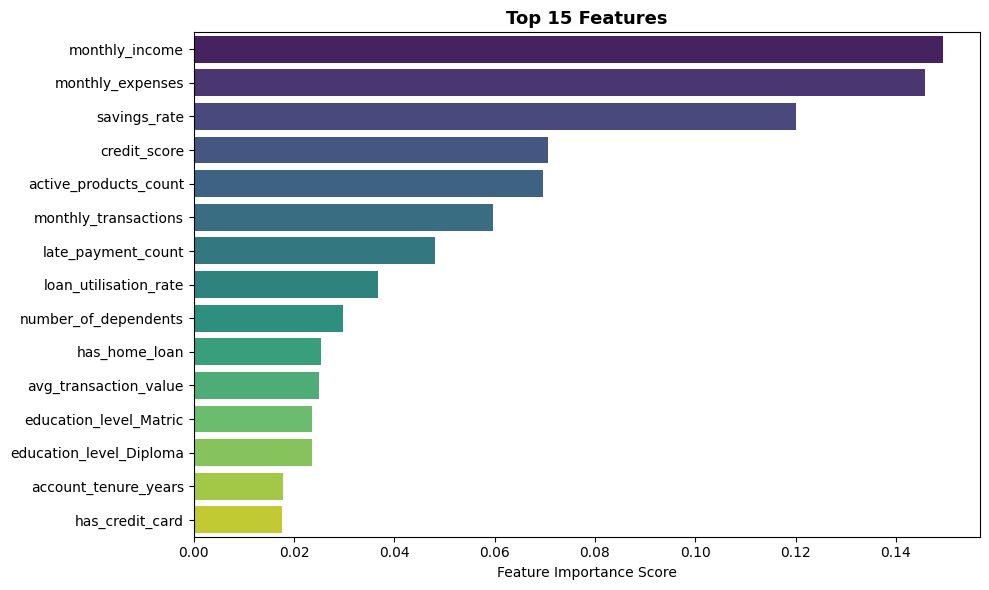

In [173]:
# Extract and plot feature importance
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': classifier.feature_importances_
}).sort_values('importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=importance_df, x='importance', y='feature', 
            palette='viridis', ax=ax)
ax.set_title("Top 15 Features",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Feature Importance Score")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

In [165]:
def predict_customer(customer_dict):
    """
    Predicts the cluster and recommended products for a new customer.
    
    Parameters
    ----------
    customer_dict : dict — new customer features (raw, unscaled values)
    
    Returns
    -------
    dict with cluster_id, cluster_name, and product recommendations
    """
    # Convert to DataFrame
    customer_df = pd.DataFrame([customer_dict])
    
    # Apply same encoding as training data
    customer_encoded = pd.get_dummies(
        customer_df,
        columns=categorical_to_encode,
        drop_first=True
    )
    
    # Align columns with training data. Add missing columns as 0
    # to handle cases where a category wasn't seen in the new customer
    customer_encoded = customer_encoded.reindex(
        columns=feature_cols, fill_value=0
    )
    
    # Predict cluster
    predicted_cluster    = classifier.predict(customer_encoded)[0]
    predicted_cluster_name = cluster_names[predicted_cluster]
    
    # Get cluster profile for eligibility checking
    profile_row = cluster_profile.loc[predicted_cluster]
    
    # Override profile with actual customer values for more better recommendations
    profile_row = profile_row.copy()
    profile_row['monthly_income'] = customer_dict.get('monthly_income', profile_row['monthly_income'])
    profile_row['credit_score']   = customer_dict.get('credit_score',   profile_row['credit_score'])
    
    # Get recommendations
    recs = recommend_products_for_cluster(predicted_cluster_name, profile_row, top_n=3)
    
    print(f"\n{'=' * 55}")
    print(f"  NEW CUSTOMER PREDICTION")
    print(f"{'=' * 55}")
    print(f"  Predicted Segment : {predicted_cluster_name}")
    print(f"  Cluster ID        : {predicted_cluster}")
    print(f"\n  Recommended Products:")
    for i, rec in enumerate(recs, 1):
        print(f"  {i}. {rec['product']}")
        print(f"     → {rec['description']}")
    print(f"{'=' * 55}\n")
    
    return {
        'cluster_id':    predicted_cluster,
        'cluster_name':  predicted_cluster_name,
        'recommendations': recs
    }


In [166]:
# Try predicting a new customer
new_customer = {
    'age': 34,
    'gender': 'Female',
    'marital_status': 'Married',
    'number_of_dependents': 2,
    'education_level': 'Undergraduate',
    'province': 'Gauteng',
    'employment_status': 'Employed',
    'monthly_income': 35000,
    'savings_rate': 0.28,
    'account_tenure_years': 5,
    'monthly_transactions': 18,
    'avg_transaction_value': 850,
    'digital_login_frequency': 22,
    'branch_visit_count': 2,
    'late_payment_count': 0,
    'has_savings_account': 1,
    'has_credit_card': 1,
    'has_home_loan': 0,
    'has_personal_loan': 0,
    'has_vehicle_finance': 0,
    'has_investment_account': 0,
    'active_products_count': 2,
    'credit_score': 680,
    'loan_utilisation_rate': 0.25,
    'days_since_last_default': 0,
    'has_ever_defaulted': 0
}

result = predict_customer(new_customer)


  NEW CUSTOMER PREDICTION
  Predicted Segment : Stable Middles
  Cluster ID        : 0

  Recommended Products:
  1. Fixed Deposit
     → Guaranteed return savings over a fixed term
  2. Overdraft Facility
     → Short-term credit buffer linked to cheque account
  3. Revolving Credit
     → Flexible credit facility that replenishes as you repay



# 5. AI Generated Executive Summaries